✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px

--- Thinning ---


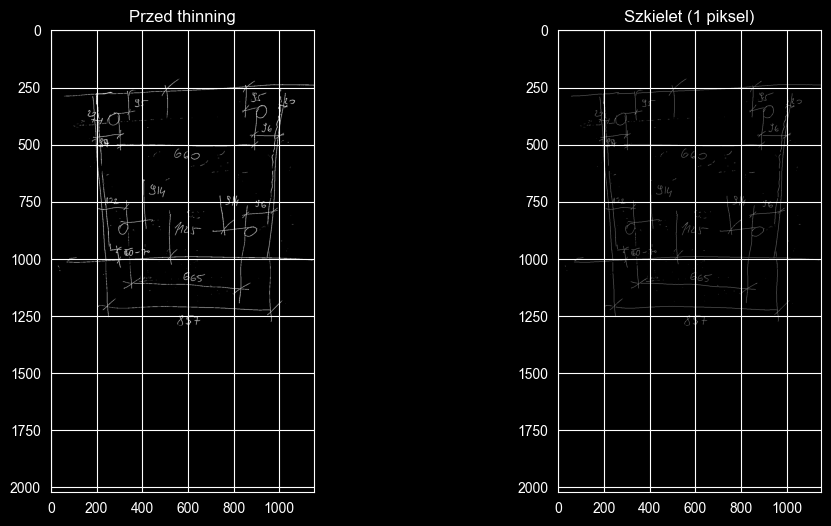

Wyodrębniono 267 segmentów (linii)
Dopasowano 267 linii (przed wymuszeniem)
Po klasyfikacji: main=27, ticks=21, other=219

--- Detekcja okręgów ---
Wykryto okręgów: 0
Węzłów: 84
Krawędzi: 48
Narożniki (stopień≥2): 11


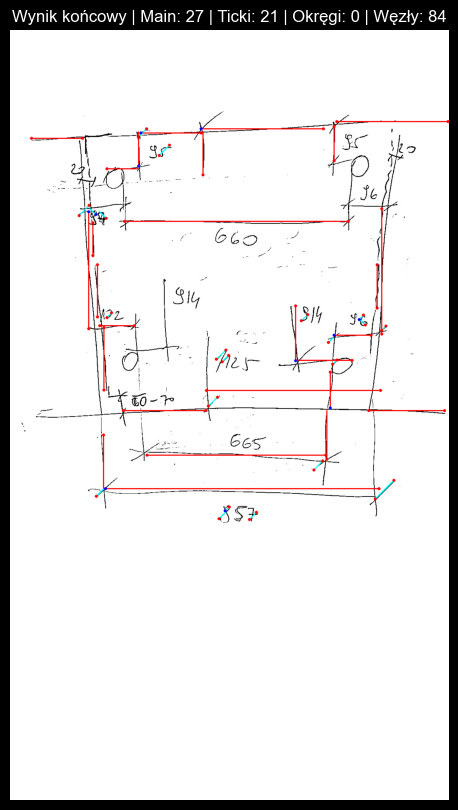


✅ Zapisano:
   JSON: C:\python\Intelligent_Sketch2CAD\intermediate_data\final_tracing_20260511_000819.json
   Obraz: C:\python\Intelligent_Sketch2CAD\intermediate_data\final_tracing_20260511_000819.jpg

Gotowe do użycia w FreeCAD (linie główne i okręgi).


In [2]:
# -------------------------------
# FINAL: SKETCH → CAD (thinning + graph tracing + fitLine)
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
from collections import defaultdict, deque

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD LATEST adaptive_cleaned_*.jpg
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found. Run preprocessing first.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image

# Polaryzacja: białe tło, czarne linie
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed (white background, black lines)")

# ============================================================
# PREPROCESSING (filtracja komponentów – identyczna jak poprzednio)
# ============================================================
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found – keeping original")
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    area_main = cv2.contourArea(main_contour)
    print(f"Main contour area: {area_main:.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    kernel_large = np.ones((120, 120), np.uint8)
    mask_near = cv2.dilate(mask_edge, kernel_large, iterations=1)
    mask_near_or_bottom = mask_near

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)

    mask_final = np.zeros_like(gray, dtype=np.uint8)
    MAX_AREA_SMALL = 1500

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]

        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near_or_bottom).any() and area < MAX_AREA_SMALL:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

# ============================================================
# 1. THINNING
# ============================================================
print("\n--- Thinning ---")
binary_thin = cv2.bitwise_not(gray)   # linie białe na czarnym tle
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)

# Do dalszego przetwarzania używamy skeleton (linie = 255)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(binary_thin, cmap='gray'); plt.title("Przed thinning")
plt.subplot(1,2,2); plt.imshow(skeleton, cmap='gray'); plt.title("Szkielet (1 piksel)")
plt.show()

# ============================================================
# 2. TRACING SEGMENTS USING NEIGHBORHOOD DEGREE
# ============================================================
# Przygotuj tablicę z odwiedzinami
h, w = skeleton.shape
visited = np.zeros((h, w), dtype=bool)

# 8 sąsiadów
neighbors8 = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

def get_degree(y, x):
    """Liczba białych sąsiadów w 8-sąsiedztwie (wartości 255)"""
    if skeleton[y,x] == 0:
        return 0
    cnt = 0
    for dy, dx in neighbors8:
        ny, nx = y+dy, x+dx
        if 0 <= ny < h and 0 <= nx < w and skeleton[ny,nx] == 255:
            cnt += 1
    return cnt

# Lista wszystkich pikseli linii
points = list(zip(*np.where(skeleton == 255)))

# Mapowanie współrzędnych -> indeks (dla szybkiego dostępu)
point_index = {}
for i, (y,x) in enumerate(points):
    point_index[(y,x)] = i

# Zbiory do przechowania segmentów (każdy segment to lista punktów (y,x) w kolejności)
segments = []

# BFS/DFS do wyodrębniania ścieżek między węzłami (stopień !=2) lub końcami
for y, x in points:
    if visited[y,x]:
        continue
    # Start nowego segmentu
    # Jeśli stopień = 2, możemy zacząć, ale zachowujemy ostrożność – lepiej zaczynać od końców (stopień 1) lub węzłów (>2)
    # Dla uproszczenia zaczynamy od każdego nieodwiedzonego piksela o stopniu !=2 (lub też stopień 2, jeśli jeszcze nieodwiedzony,
    # ale to grozi pominięciem fragmentów. Zastosujemy: zawsze zaczynaj od stopnia 1 lub >=3, a dla stopnia 2 - tylko jeśli nie jest częścią żadnego segmentu)
    # Implementacja: użyjemy metody "podążaj w obie strony" od każdego nieodwiedzonego piksela o stopniu !=2.
    deg = get_degree(y,x)
    if deg == 2:
        continue   # poczekamy aż natrafimy na niego z innego miejsca

    # Zbieramy całą ścieżkę
    segment_points = []
    # Przeszukiwanie w dwóch kierunkach (od startu)
    for start_dir in [1, -1]:
        py, px = y, x
        prev_y, prev_x = -1, -1
        while True:
            if visited[py,px]:
                break
            visited[py,px] = True
            segment_points.append((py,px))
            # Znajdź następny nieodwiedzony sąsiad (pomijając poprzedni)
            next_pts = []
            for dy,dx in neighbors8:
                ny, nx = py+dy, px+dx
                if 0 <= ny < h and 0 <= nx < w and skeleton[ny,nx] == 255 and not visited[ny,nx] and (ny,nx) != (prev_y, prev_x):
                    next_pts.append((ny,nx))
            if len(next_pts) == 0:
                break
            # Priorytet: wybierz sąsiada o stopniu 2 (aby iść prosto), a jeśli nie ma to dowolny
            best = None
            for ny,nx in next_pts:
                d = get_degree(ny,nx)
                if d == 2:
                    best = (ny,nx)
                    break
            if best is None:
                best = next_pts[0]
            prev_y, prev_x = py, px
            py, px = best
        # Odwróć kolejność dla drugiego kierunku? Uwaga: startowy piksel dodajemy tylko raz
    # segment_points zawiera punkty w kolejności od jednego końca do drugiego (bo start był końcem lub węzłem)
    if len(segment_points) > 5:   # minimalna długość
        segments.append(segment_points)

# Dodatkowo: jeśli pozostały jakieś nieodwiedzone punkty o stopniu 2 (np. zamknięte pętle okręgów – osobna obsługa)
# Dla nich też trzeba wyodrębnić ścieżki, ale będą to cykle. Na razie pomijamy – okręgi wykryjemy osobno.
# Ale dla bezpieczeństwa: znajdź nieodwiedzone punkty stopnia 2 i potraktuj jako segmenty liniowe (mogą to być fragmenty)
remaining = []
for y,x in points:
    if not visited[y,x] and get_degree(y,x) == 2:
        remaining.append((y,x))
if remaining:
    # Proste BFS dla każdego z nich (tworząc otwarte segmenty)
    visited_rem = np.zeros((h,w), dtype=bool)
    for y,x in remaining:
        if visited_rem[y,x]:
            continue
        # BFS wzdłuż 8-sąsiedztwa, tylko stopień 2 (i nieodwiedzone)
        queue = deque()
        queue.append((y,x))
        visited_rem[y,x] = True
        seg = []
        while queue:
            cy,cx = queue.popleft()
            seg.append((cy,cx))
            for dy,dx in neighbors8:
                ny,nx = cy+dy, cx+dx
                if 0 <= ny < h and 0 <= nx < w and skeleton[ny,nx]==255 and not visited_rem[ny,nx] and get_degree(ny,nx)==2:
                    visited_rem[ny,nx] = True
                    queue.append((ny,nx))
        if len(seg) > 5:
            segments.append(seg)

print(f"Wyodrębniono {len(segments)} segmentów (linii)")

# ============================================================
# 3. DOPASOWANIE PROSTEJ (fitLine) i WYMIUSZENIE KĄTÓW
# ============================================================
def fit_line_to_points(pts):
    """pts: lista (y,x). Zwraca (x1,y1,x2,y2) jako odcinek prostej dopasowanej."""
    if len(pts) < 2:
        return None
    points_np = np.array([(x,y) for (y,x) in pts], dtype=np.float32).reshape(-1,1,2)
    # fitLine: vx,vy,x0,y0
    vx, vy, x0, y0 = cv2.fitLine(points_np, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy = vx[0], vy[0]
    x0, y0 = x0[0], y0[0]
    # Oblicz rzuty wszystkich punktów na prostą
    t_vals = []
    for (x,y) in points_np.reshape(-1,2):
        t = ( (x - x0)*vx + (y - y0)*vy ) / (vx*vx + vy*vy + 1e-8)
        t_vals.append(t)
    t_min, t_max = min(t_vals), max(t_vals)
    x1 = x0 + t_min * vx
    y1 = y0 + t_min * vy
    x2 = x0 + t_max * vx
    y2 = y0 + t_max * vy
    return [int(x1), int(y1), int(x2), int(y2)]

def enforce_angle(line, target_angle):
    """Wymusza kąt odcinka na target_angle (stopnie). Zwraca nowy odcinek (x1,y1,x2,y2) z zachowaniem środka."""
    x1,y1,x2,y2 = line
    cx = (x1+x2)/2
    cy = (y1+y2)/2
    length = np.hypot(x2-x1, y2-y1)
    if length < 1:
        return line
    rad = np.radians(target_angle)
    dx = length * np.cos(rad)
    dy = length * np.sin(rad)
    new_line = [int(cx - dx/2), int(cy - dy/2), int(cx + dx/2), int(cy + dy/2)]
    return new_line

# Klasyfikuj i przetwarzaj każdy segment
raw_lines = []   # (x1,y1,x2,y2, length, angle_deg, raw_angle)
for seg in segments:
    if len(seg) < 5:
        continue
    line = fit_line_to_points(seg)
    if line is None:
        continue
    x1,y1,x2,y2 = line
    length = np.hypot(x2-x1, y2-y1)
    angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
    raw_lines.append((x1,y1,x2,y2, length, angle))

print(f"Dopasowano {len(raw_lines)} linii (przed wymuszeniem)")

# Wymuszanie kątów i klasyfikacja
lines_main = []   # długie poziome/pionowe (kąt 0 lub 90)
lines_ticks = []  # krótkie 45°
lines_other = []

for (x1,y1,x2,y2, length, raw_angle) in raw_lines:
    # Decyzja: celowany kąt
    target = None
    if length > 80:
        # poziome: kąt bliski 0 lub 180 -> 0
        if raw_angle < 15 or raw_angle > 165:
            target = 0
        # pionowe: kąt bliski 90
        elif 75 < raw_angle < 105:
            target = 90
        else:
            target = None
    elif 15 <= length <= 80:
        # tick 45°
        if 35 < raw_angle < 55:
            target = 45
        elif 125 < raw_angle < 145:
            target = 135
        else:
            target = None
    else:
        target = None

    if target is not None:
        new_line = enforce_angle([x1,y1,x2,y2], target)
        nx1,ny1,nx2,ny2 = new_line
        # Nowa długość po wymuszeniu
        new_len = np.hypot(nx2-nx1, ny2-ny1)
        if length > 80:
            lines_main.append([nx1,ny1,nx2,ny2])
        else:
            lines_ticks.append([nx1,ny1,nx2,ny2])
    else:
        # nie wymuszaj, dodaj jako inne
        lines_other.append([x1,y1,x2,y2])

print(f"Po klasyfikacji: main={len(lines_main)}, ticks={len(lines_ticks)}, other={len(lines_other)}")

# ============================================================
# 4. OKRĘGI (HoughCircles na oryginalnym gray przed thinning)
# ============================================================
print("\n--- Detekcja okręgów ---")
circles = []
gray_orig = gray  # obraz przed thinning (białe tło, czarne linie)
circles_raw = cv2.HoughCircles(gray_orig, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                               param1=100, param2=40, minRadius=5, maxRadius=80)
if circles_raw is not None:
    circles_raw = np.round(circles_raw[0, :]).astype("int")
    for (x,y,r) in circles_raw:
        # Weryfikacja pokrycia
        mask_circ = np.zeros_like(gray_orig, dtype=np.uint8)
        cv2.circle(mask_circ, (x,y), r, 255, 2)
        overlap = cv2.bitwise_and(gray_orig, mask_circ)
        coverage = np.sum(overlap == 0) / (np.sum(mask_circ == 255) + 1e-6)
        if coverage > 0.5:
            circles.append([x,y,r])
print(f"Wykryto okręgów: {len(circles)}")

# ============================================================
# 5. BUDOWANIE WĘZŁÓW (z linii main i tick)
# ============================================================
all_lines = lines_main + lines_ticks
proximity_threshold = 10
nodes = []
edges = []

def find_or_add_node(x, y):
    for i, (nx, ny) in enumerate(nodes):
        if abs(nx-x) < proximity_threshold and abs(ny-y) < proximity_threshold:
            return i
    nodes.append((int(x), int(y)))
    return len(nodes)-1

for idx, (x1,y1,x2,y2) in enumerate(all_lines):
    n1 = find_or_add_node(x1, y1)
    n2 = find_or_add_node(x2, y2)
    typ = "main" if idx < len(lines_main) else "tick"
    edges.append((n1, n2, typ, idx))

node_degree = defaultdict(int)
for e in edges:
    node_degree[e[0]] += 1
    node_degree[e[1]] += 1
corner_nodes = [i for i, deg in node_degree.items() if deg >= 2]

print(f"Węzłów: {len(nodes)}")
print(f"Krawędzi: {len(edges)}")
print(f"Narożniki (stopień≥2): {len(corner_nodes)}")

# ============================================================
# 6. WIZUALIZACJA KOŃCOWA
# ============================================================
vis = cv2.cvtColor(gray_orig, cv2.COLOR_GRAY2BGR)
for (x1,y1,x2,y2) in lines_main:
    cv2.line(vis, (x1,y1), (x2,y2), (255,0,0), 2)
for (x1,y1,x2,y2) in lines_ticks:
    cv2.line(vis, (x1,y1), (x2,y2), (0,255,255), 2)
for (x,y,r) in circles:
    cv2.circle(vis, (x,y), r, (0,255,0), 2)
for i, (x,y) in enumerate(nodes):
    color = (0,0,255) if i in corner_nodes else (255,0,0)
    cv2.circle(vis, (x,y), 4, color, -1)

plt.figure(figsize=(14,10))
plt.imshow(vis)
plt.title(f"Wynik końcowy | Main: {len(lines_main)} | Ticki: {len(lines_ticks)} | Okręgi: {len(circles)} | Węzły: {len(nodes)}")
plt.axis('off')
plt.show()

# ============================================================
# 7. ZAPIS DO JSON
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "method": "thinning + graph_tracing + fitLine + angle_enforce",
    "statistics": {
        "main_lines": len(lines_main),
        "ticks": len(lines_ticks),
        "other_lines": len(lines_other),
        "circles": len(circles),
        "nodes": len(nodes),
        "edges": len(edges),
        "corner_nodes": len(corner_nodes)
    },
    "lines": {
        "main": lines_main,
        "ticks": lines_ticks,
        "other": lines_other
    },
    "circles": circles,
    "graph": {
        "nodes": nodes,
        "edges": [[e[0], e[1], e[2], e[3]] for e in edges],
        "corner_nodes": corner_nodes
    }
}

json_path = INTERMEDIATE_DIR / f"final_tracing_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

final_img_path = INTERMEDIATE_DIR / f"final_tracing_{timestamp}.jpg"
cv2.imwrite(str(final_img_path), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

print(f"\n✅ Zapisano:\n   JSON: {json_path}\n   Obraz: {final_img_path}")
print("\nGotowe do użycia w FreeCAD (linie główne i okręgi).")

✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px

--- Krok 1: Thinning ---


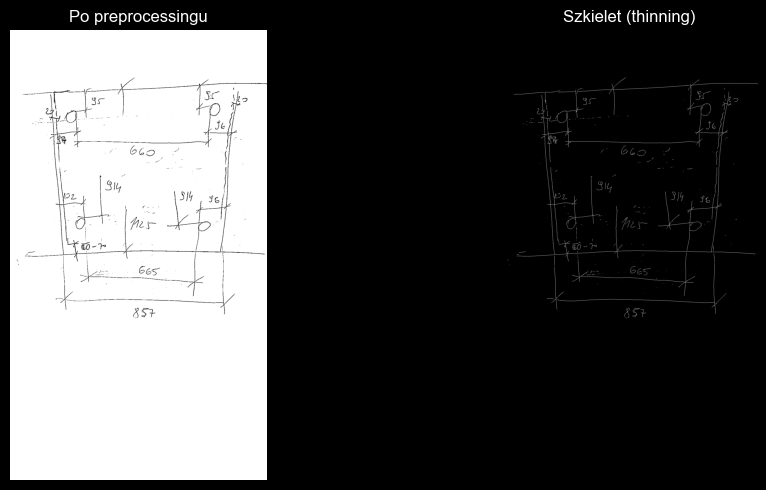

Obraz: 2022x1152 px

--- Krok 2: Projekcje ---


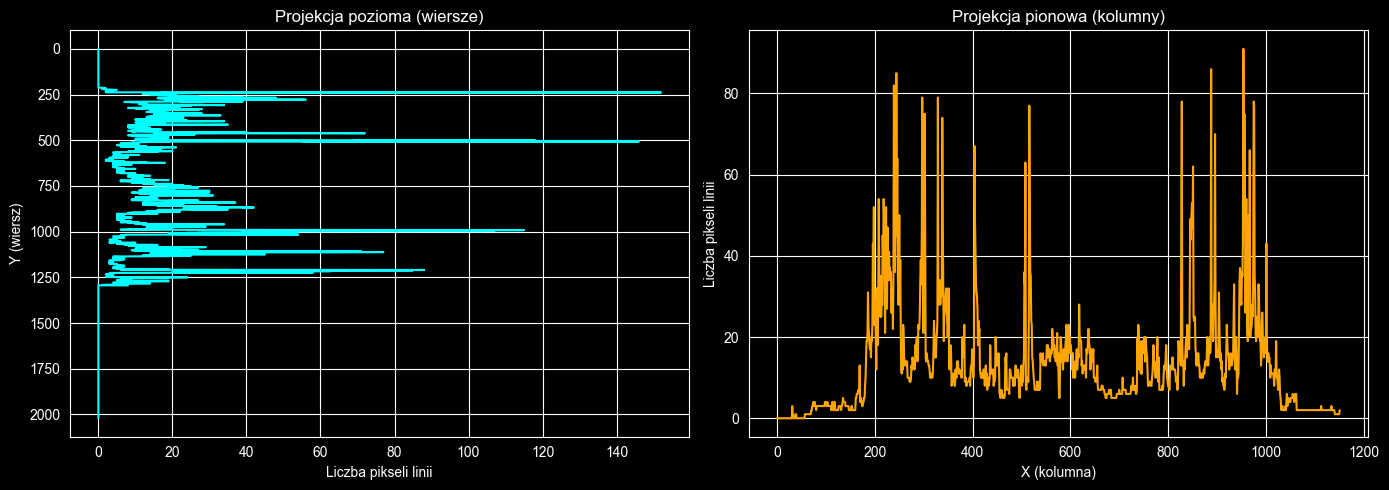

Wykryte linie poziome (Y): [240, 266, 307, 335, 364, 392, 457, 504, 747, 777, 830, 871, 960, 1000, 1086, 1113, 1214, 1250]
Wykryte linie pionowe (X): [192, 241, 280, 308, 343, 381, 412, 448, 507, 542, 572, 601, 637, 739, 770, 797, 824, 854, 896, 935, 976, 1021]


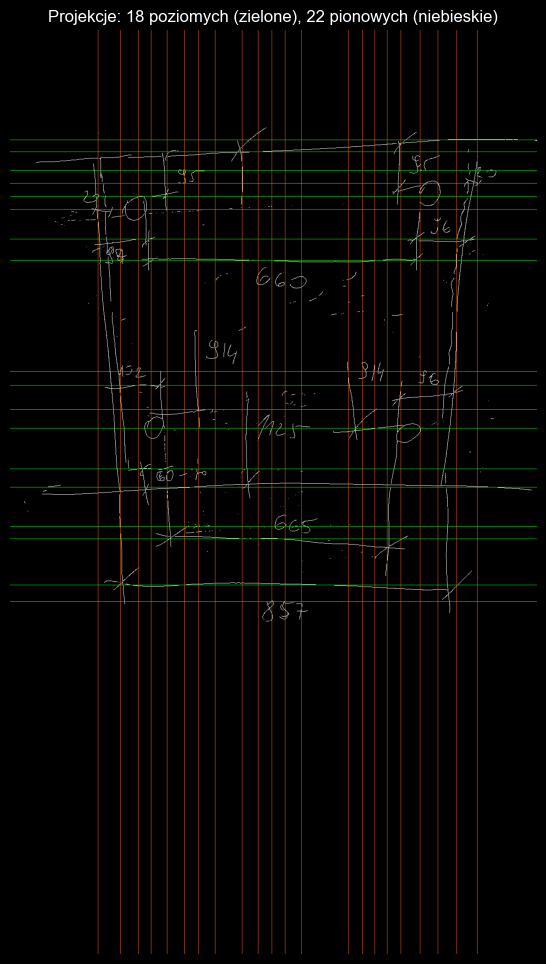


--- Krok 3: Klasyfikacja linii ---
Linie poziome:
  Y= 240  typ=auxiliary   siła=1.00
  Y= 266  typ=main        siła=0.26
  Y= 307  typ=dimension   siła=0.22
  Y= 335  typ=dimension   siła=0.18
  Y= 364  typ=dimension   siła=0.22
  Y= 392  typ=dimension   siła=0.16
  Y= 457  typ=main        siła=0.26
  Y= 504  typ=auxiliary   siła=0.96
  Y= 747  typ=dimension   siła=0.15
  Y= 777  typ=dimension   siła=0.20
  Y= 830  typ=dimension   siła=0.18
  Y= 871  typ=main        siła=0.28
  Y= 960  typ=dimension   siła=0.22
  Y=1000  typ=auxiliary   siła=0.76
  Y=1086  typ=dimension   siła=0.19
  Y=1113  typ=main        siła=0.51
  Y=1214  typ=main        siła=0.58
  Y=1250  typ=dimension   siła=0.16
Linie pionowe:
  X= 192  typ=main        siła=0.57
  X= 241  typ=auxiliary   siła=0.93
  X= 280  typ=dimension   siła=0.15
  X= 308  typ=dimension   siła=0.18
  X= 343  typ=auxiliary   siła=0.81
  X= 381  typ=main        siła=0.25
  X= 412  typ=main        siła=0.33
  X= 448  typ=dimension   siła=0.2

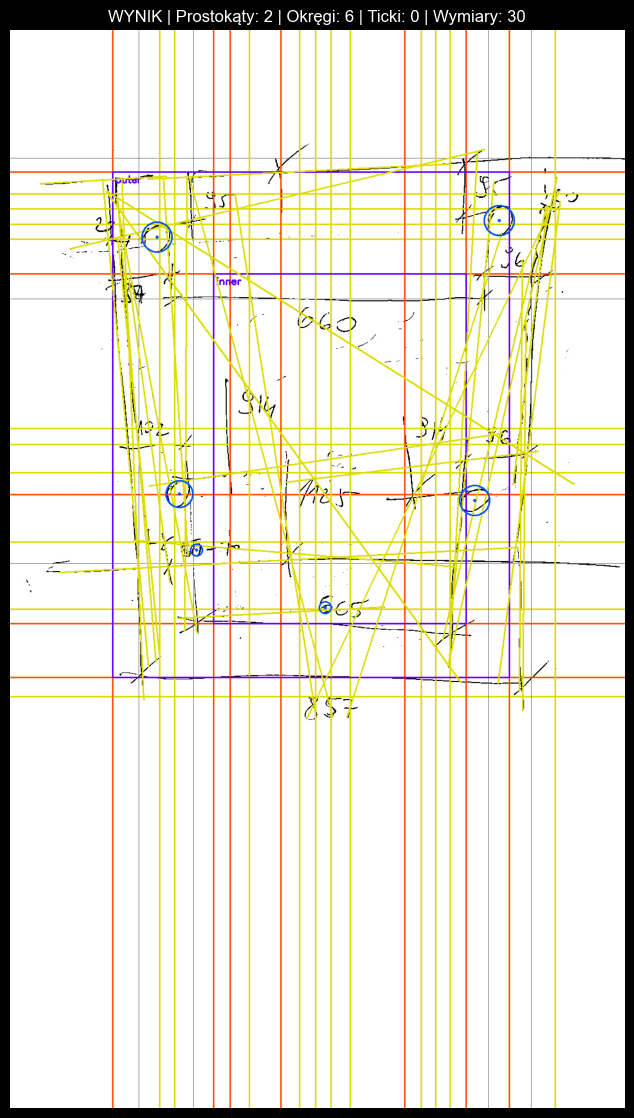


✅ Zapisano JSON: C:\python\Intelligent_Sketch2CAD\intermediate_data\sketch_cad_20260511_010513.json
   Prostokąty: 2
   Okręgi: 6
   Linie pomocnicze poziome: 3
   Linie główne poziome: 5
   Ticki: 0

Następny krok: załaduj JSON do FreeCAD przez skrypt Python → DXF


In [4]:
# -------------------------------
# SKETCH → CAD v3: projekcje + RANSAC + okręgi
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# ============================================================
# PREPROCESSING (Twój oryginalny - bez zmian)
# ============================================================
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    area_main = cv2.contourArea(main_contour)
    print(f"Main contour area: {area_main:.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    kernel_large = np.ones((120, 120), np.uint8)
    mask_near = cv2.dilate(mask_edge, kernel_large, iterations=1)

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)

    mask_final = np.zeros_like(gray, dtype=np.uint8)
    MAX_AREA_SMALL = 1500

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < MAX_AREA_SMALL:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

# ============================================================
# 1. THINNING
# ============================================================
print("\n--- Krok 1: Thinning ---")
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap='gray'); plt.title("Po preprocessingu"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(skeleton, cmap='gray'); plt.title("Szkielet (thinning)"); plt.axis('off')
plt.tight_layout(); plt.show()

h, w = skeleton.shape
print(f"Obraz: {h}x{w} px")

# ============================================================
# 2. PROJEKCJE — wykrycie głównych linii poziomych i pionowych
# ============================================================
print("\n--- Krok 2: Projekcje ---")

# Piksele linii (białe na czarnym)
line_pixels = (skeleton == 255).astype(np.uint8)

# Projekcja pozioma: suma pikseli w każdym wierszu
proj_h = np.sum(line_pixels, axis=1).astype(float)
# Projekcja pionowa: suma pikseli w każdej kolumnie
proj_v = np.sum(line_pixels, axis=0).astype(float)

# Wizualizacja projekcji
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(proj_h, np.arange(h), color='cyan')
plt.gca().invert_yaxis()
plt.title("Projekcja pozioma (wiersze)")
plt.xlabel("Liczba pikseli linii"); plt.ylabel("Y (wiersz)")

plt.subplot(1, 2, 2)
plt.plot(np.arange(w), proj_v, color='orange')
plt.title("Projekcja pionowa (kolumny)")
plt.xlabel("X (kolumna)"); plt.ylabel("Liczba pikseli linii")
plt.tight_layout(); plt.show()

def find_peaks_robust(signal, min_val=None, min_dist=30):
    """Znajdź piki w sygnale projekcji — miejsca gdzie są linie."""
    if min_val is None:
        min_val = np.max(signal) * 0.15  # próg: 15% maksimum
    peaks = []
    i = 0
    while i < len(signal):
        if signal[i] >= min_val:
            # Znajdź koniec plateau
            j = i
            while j < len(signal) and signal[j] >= min_val:
                j += 1
            # Środek plateau = pozycja linii
            peak_pos = (i + j) // 2
            peak_val = np.max(signal[i:j])
            peaks.append((peak_pos, peak_val))
            i = j + min_dist
        else:
            i += 1
    return peaks

h_peaks = find_peaks_robust(proj_h, min_dist=25)
v_peaks = find_peaks_robust(proj_v, min_dist=25)

print(f"Wykryte linie poziome (Y): {[p[0] for p in h_peaks]}")
print(f"Wykryte linie pionowe (X): {[p[0] for p in v_peaks]}")

# Wizualizacja wykrytych linii na szkielecie
vis_proj = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
for (y, val) in h_peaks:
    cv2.line(vis_proj, (0, y), (w, y), (0, 255, 0), 1)
for (x, val) in v_peaks:
    cv2.line(vis_proj, (x, 0), (x, h), (255, 100, 0), 1)

plt.figure(figsize=(8, 12))
plt.imshow(vis_proj)
plt.title(f"Projekcje: {len(h_peaks)} poziomych (zielone), {len(v_peaks)} pionowych (niebieskie)")
plt.axis('off'); plt.show()

# ============================================================
# 3. KLASYFIKACJA LINII PROJEKCJI
# ============================================================
print("\n--- Krok 3: Klasyfikacja linii ---")

# Sortuj po Y / X
h_peaks_sorted = sorted(h_peaks, key=lambda p: p[0])
v_peaks_sorted = sorted(v_peaks, key=lambda p: p[0])

h_ys = [p[0] for p in h_peaks_sorted]
v_xs = [p[0] for p in v_peaks_sorted]

# Klasyfikacja przez siłę sygnału i pozycję
# Linie pomocnicze = rozciągają się przez całą szerokość (duży sygnał)
# Linie główne = prostokąt obiektu
# Linie wymiarowe = słabszy sygnał, poza prostokątem

max_h = max(proj_h)
max_v = max(proj_v)

lines_horizontal = []   # (y, typ, strength)
for (y, val) in h_peaks_sorted:
    strength = val / max_h
    if strength > 0.7:
        typ = "auxiliary"   # przez całą szerokość
    elif strength > 0.25:
        typ = "main"        # krawędź prostokąta
    else:
        typ = "dimension"   # linia wymiarowa
    lines_horizontal.append({"y": int(y), "type": typ, "strength": round(strength, 3)})

lines_vertical = []
for (x, val) in v_peaks_sorted:
    strength = val / max_v
    if strength > 0.7:
        typ = "auxiliary"
    elif strength > 0.25:
        typ = "main"
    else:
        typ = "dimension"
    lines_vertical.append({"x": int(x), "type": typ, "strength": round(strength, 3)})

print("Linie poziome:")
for l in lines_horizontal:
    print(f"  Y={l['y']:4d}  typ={l['type']:10s}  siła={l['strength']:.2f}")
print("Linie pionowe:")
for l in lines_vertical:
    print(f"  X={l['x']:4d}  typ={l['type']:10s}  siła={l['strength']:.2f}")

# Wyciągnij prostokąty z linii "main"
main_h = [l['y'] for l in lines_horizontal if l['type'] == 'main']
main_v = [l['x'] for l in lines_vertical if l['type'] == 'main']

rectangles = []
if len(main_h) >= 2 and len(main_v) >= 2:
    # Największy prostokąt = zewnętrzny
    y_top, y_bot = min(main_h), max(main_h)
    x_left, x_right = min(main_v), max(main_v)
    rectangles.append({
        "label": "outer",
        "x1": x_left, "y1": y_top,
        "x2": x_right, "y2": y_bot,
        "width_px": x_right - x_left,
        "height_px": y_bot - y_top
    })
    # Jeśli są więcej linii main — drugi prostokąt (wewnętrzny)
    if len(main_h) >= 4 and len(main_v) >= 4:
        inner_h = sorted(main_h)[1:-1]
        inner_v = sorted(main_v)[1:-1]
        if inner_h and inner_v:
            rectangles.append({
                "label": "inner",
                "x1": min(inner_v), "y1": min(inner_h),
                "x2": max(inner_v), "y2": max(inner_h),
                "width_px": max(inner_v) - min(inner_v),
                "height_px": max(inner_h) - min(inner_h)
            })

print(f"\nWykryte prostokąty: {len(rectangles)}")
for r in rectangles:
    print(f"  {r['label']}: ({r['x1']},{r['y1']}) → ({r['x2']},{r['y2']})  {r['width_px']}x{r['height_px']} px")

# ============================================================
# 4. DETEKCJA OKRĘGÓW — przez kontury na szkielecie
# ============================================================
print("\n--- Krok 4: Okręgi przez kontury ---")

# Szukamy zamkniętych, okrągłych konturów na szkielecie
# Morfologia: zamknij małe przerwy w okręgach
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)

circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 200 or area > 15000:
        continue
    perimeter = cv2.arcLength(cnt, True)
    if perimeter < 1:
        continue
    # Circularity: 4π·area/perimeter² = 1 dla idealnego okręgu
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.55:  # próg okrągłości
        (cx, cy), radius = cv2.minEnclosingCircle(cnt)
        circles.append({
            "cx": int(cx), "cy": int(cy),
            "radius_px": int(radius),
            "radius_mm": None,  # do uzupełnienia ręcznie lub przez skalę
            "circularity": round(circularity, 3)
        })

# Usuń duplikaty (okręgi blisko siebie)
circles_clean = []
for c in circles:
    duplicate = False
    for existing in circles_clean:
        dist = np.hypot(c['cx'] - existing['cx'], c['cy'] - existing['cy'])
        if dist < 20:
            duplicate = True
            break
    if not duplicate:
        circles_clean.append(c)

circles = circles_clean
print(f"Wykryte okręgi: {len(circles)}")
for c in circles:
    print(f"  ({c['cx']}, {c['cy']})  r={c['radius_px']}px  okrągłość={c['circularity']:.2f}")

# ============================================================
# 5. LINIE WYMIAROWE — RANSAC na szkielecie
# ============================================================
print("\n--- Krok 5: Linie ukośne (ticki wymiarowe) ---")

# Zbierz wszystkie piksele szkieletu
ys, xs = np.where(skeleton == 255)
all_pts = list(zip(xs.tolist(), ys.tolist()))  # (x, y)

# Usuń piksele które leżą blisko wykrytych linii głównych (poziomych i pionowych)
MARGIN = 8
def near_main_line(x, y):
    for lh in lines_horizontal:
        if lh['type'] in ('main', 'auxiliary') and abs(y - lh['y']) < MARGIN:
            return True
    for lv in lines_vertical:
        if lv['type'] in ('main', 'auxiliary') and abs(x - lv['x']) < MARGIN:
            return True
    return False

remaining_pts = [(x, y) for (x, y) in all_pts if not near_main_line(x, y)]
print(f"Pozostałe piksele po odjęciu linii głównych: {len(remaining_pts)}")

# Prosta detekcja ticków: szukaj małych grup pikseli pod kątem ~45°
def ransac_line(pts, n_iter=50, threshold=2.0, min_inliers=15):
    """Prosty RANSAC dla odcinka prostej."""
    if len(pts) < min_inliers:
        return None, []
    pts_np = np.array(pts, dtype=float)
    best_inliers = []
    for _ in range(n_iter):
        idx = np.random.choice(len(pts_np), 2, replace=False)
        p1, p2 = pts_np[idx[0]], pts_np[idx[1]]
        dx, dy = p2 - p1
        length = np.hypot(dx, dy)
        if length < 5:
            continue
        # Odległość punktów od prostej
        nx, ny = -dy / length, dx / length
        dists = np.abs((pts_np[:, 0] - p1[0]) * nx + (pts_np[:, 1] - p1[1]) * ny)
        inliers = pts_np[dists < threshold]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
    if len(best_inliers) < min_inliers:
        return None, []
    # fitLine na inlierach
    pts_fit = best_inliers.astype(np.float32).reshape(-1, 1, 2)
    vx, vy, x0, y0 = cv2.fitLine(pts_fit, cv2.DIST_L2, 0, 0.01, 0.01)
    vx, vy, x0, y0 = vx[0], vy[0], x0[0], y0[0]
    t_vals = [(((p[0]-x0)*vx + (p[1]-y0)*vy)) for p in best_inliers]
    t_min, t_max = min(t_vals), max(t_vals)
    x1 = int(x0 + t_min * vx); y1 = int(y0 + t_min * vy)
    x2 = int(x0 + t_max * vx); y2 = int(y0 + t_max * vy)
    return [x1, y1, x2, y2], list(map(tuple, best_inliers.astype(int).tolist()))

# Iteracyjny RANSAC — wyodrębnij kolejne linie
tick_lines = []
pts_work = remaining_pts.copy()
MAX_LINES = 30

for iteration in range(MAX_LINES):
    if len(pts_work) < 20:
        break
    line, inliers = ransac_line(pts_work, n_iter=80, threshold=2.5, min_inliers=12)
    if line is None:
        break
    x1, y1, x2, y2 = line
    length = np.hypot(x2-x1, y2-y1)
    angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180

    # Klasyfikuj ticki (kąt ~45°) vs inne linie wymiarowe
    is_tick = (30 < angle < 60 or 120 < angle < 150) and length < 100
    is_dim = length > 30 and not is_tick

    if is_tick or is_dim:
        tick_lines.append({
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "length_px": round(length, 1),
            "angle_deg": round(angle, 1),
            "type": "tick" if is_tick else "dimension_diagonal"
        })

    # Usuń inlierów z puli
    inlier_set = set(inliers)
    pts_work = [(x, y) for (x, y) in pts_work if (x, y) not in inlier_set]

print(f"Linie ukośne/wymiarowe: {len(tick_lines)}")

# ============================================================
# 6. WIZUALIZACJA KOŃCOWA
# ============================================================
print("\n--- Krok 6: Wizualizacja końcowa ---")

vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Kolory
COLOR_AUX   = (100, 100, 100)  # szary - linie pomocnicze
COLOR_MAIN  = (0, 80, 255)     # niebieski - krawędzie prostokąta
COLOR_DIM   = (0, 220, 220)    # cyan - linie wymiarowe
COLOR_TICK  = (0, 200, 100)    # zielony - ticki
COLOR_CIRC  = (255, 80, 0)     # pomarańczowy - okręgi
COLOR_RECT  = (255, 0, 100)    # różowy - prostokąt

# Rysuj linie z projekcji
for l in lines_horizontal:
    color = COLOR_AUX if l['type'] == 'auxiliary' else (COLOR_MAIN if l['type'] == 'main' else COLOR_DIM)
    thickness = 1 if l['type'] == 'auxiliary' else 2
    cv2.line(vis_final, (0, l['y']), (w, l['y']), color, thickness)

for l in lines_vertical:
    color = COLOR_AUX if l['type'] == 'auxiliary' else (COLOR_MAIN if l['type'] == 'main' else COLOR_DIM)
    thickness = 1 if l['type'] == 'auxiliary' else 2
    cv2.line(vis_final, (l['x'], 0), (l['x'], h), color, thickness)

# Rysuj prostokąty
for r in rectangles:
    cv2.rectangle(vis_final, (r['x1'], r['y1']), (r['x2'], r['y2']), COLOR_RECT, 2)
    cv2.putText(vis_final, r['label'], (r['x1']+5, r['y1']+20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_RECT, 2)

# Rysuj ticki i linie wymiarowe
for tl in tick_lines:
    color = COLOR_TICK if tl['type'] == 'tick' else COLOR_DIM
    cv2.line(vis_final, (tl['x1'], tl['y1']), (tl['x2'], tl['y2']), color, 2)

# Rysuj okręgi
for c in circles:
    cv2.circle(vis_final, (c['cx'], c['cy']), c['radius_px'], COLOR_CIRC, 2)
    cv2.circle(vis_final, (c['cx'], c['cy']), 3, COLOR_CIRC, -1)

plt.figure(figsize=(10, 14))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"WYNIK | Prostokąty: {len(rectangles)} | Okręgi: {len(circles)} | Ticki: {len([t for t in tick_lines if t['type']=='tick'])} | Wymiary: {len([t for t in tick_lines if t['type']!='tick'])}")
plt.axis('off')
plt.show()

# ============================================================
# 7. ZAPIS JSON
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "projection_peaks + contour_circles + RANSAC_ticks",
    "rectangles": rectangles,
    "circles": circles,
    "lines": {
        "horizontal": lines_horizontal,
        "vertical": lines_vertical,
        "ticks_and_diagonal": tick_lines
    },
    "notes": "radius_mm in circles = null, fill manually or use scale calibration"
}

json_path = INTERMEDIATE_DIR / f"sketch_cad_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

print(f"\n✅ Zapisano JSON: {json_path}")
print(f"   Prostokąty: {len(rectangles)}")
print(f"   Okręgi: {len(circles)}")
print(f"   Linie pomocnicze poziome: {len([l for l in lines_horizontal if l['type']=='auxiliary'])}")
print(f"   Linie główne poziome: {len([l for l in lines_horizontal if l['type']=='main'])}")
print(f"   Ticki: {len([t for t in tick_lines if t['type']=='tick'])}")
print("\nNastępny krok: załaduj JSON do FreeCAD przez skrypt Python → DXF")